# Function 8 Analysis - Week 10

1. **Function description (unchanged):**  
You're optimising an eight-dimensional black-box function; each parameter influences the output (e.g., performance/accuracy), but the mechanism is unknown. The goal is to maximise the response, so we rely on BO to navigate a likely multi-modal surface while prioritising strong local maxima.

2. **Week 9 evaluated point:** `(0.047376, 0.055987, 0.028756, 0.041164, 0.589975, 0.923480, 0.229032, 0.665521)` returned **≈9.7395**, so it is a **good point**, but not better than the incumbent maximum.

3. **Analysis of last point:** The score stayed high but did not beat the best, which supports a plateau interpretation around the top ridge.

4. **Why we chose last week’s point (from Week 9 logic):** Week 9 tested an RF-guided alternative to check whether we were over-focusing on x7/x8 fine-tuning and missing signal in other dimensions.

5. **Recommendation for this week (and why):** Because we appear to be in a plateau, we assume the local landscape is smooth with limited noise. We therefore run a TuRBO-style local trust region centered on the incumbent promising basin, and inside that region we optimize an EI acquisition to pick the next point.

## Loading and Displaying the Data

We load the inputs and outputs for function 8. Week 9 `(0.047376, 0.055987, 0.028756, 0.041164, 0.589975, 0.923480, 0.229032, 0.665521)` returned **≈9.7395** and has been added to the dataset.


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_8")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Add the new points from Week 1–8
X_new_point_week_1 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.250000, 0.450000]])
y_new_point_week_1 = np.array([9.74365])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.100000, 0.100000, 0.100000, 0.400000, 0.250000, 0.450000]])
y_new_point_week_2 = np.array([9.73005])
X_new_point_week_3 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.000000, 1.000000]])
y_new_point_week_3 = np.array([9.6549])
X_new_point_week_4 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.100000, 0.350000]])
y_new_point_week_4 = np.array([9.72465])
X_new_point_week_5 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.210300, 0.700000]])
y_new_point_week_5 = np.array([9.74968782])
X_new_point_week_6 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.306800, 0.700000]])
y_new_point_week_6 = np.array([9.72708752])
X_new_point_week_7 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.220000, 0.710000]])
y_new_point_week_7 = np.array([9.74889])
X_new_point_week_8 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.601973, 0.930000, 0.190000, 0.680000]])
y_new_point_week_8 = np.array([9.7504526536355])
X_new_point_week_9 = np.array([[0.047376, 0.055987, 0.028756, 0.041164, 0.589975, 0.923480, 0.229032, 0.665521]])
y_new_point_week_9 = np.array([9.7395210926704])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


df sorted by y


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.050000,0.050000,0.050000,0.050000,0.601973,0.930000,0.190000,0.680000,9.750453
1,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.210300,0.700000,9.749688
2,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.220000,0.710000,9.748890
3,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.250000,0.450000,9.743650
4,0.047376,0.055987,0.028756,0.041164,0.589975,0.923480,0.229032,0.665521,9.739521
5,0.100000,0.100000,0.100000,0.100000,0.100000,0.400000,0.250000,0.450000,9.730050
6,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.306800,0.700000,9.727088
7,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.100000,0.350000,9.724650
8,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.000000,1.000000,9.654900
9,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [2]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'x7': [x[0, 6] for x in weekly_X],
    'x8': [x[0, 7] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 150)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 150)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,x7,x8,y,Running_Max,Status,Improvement
0,1,0.050000,0.050000,0.050000,0.050000,0.600000,0.93000,0.250000,0.450000,9.743650,9.743650,✓ NEW MAX,+9.743650
1,2,0.100000,0.100000,0.100000,0.100000,0.100000,0.40000,0.250000,0.450000,9.730050,9.743650,✗,-
2,3,0.050000,0.050000,0.050000,0.050000,0.600000,0.93000,0.000000,1.000000,9.654900,9.743650,✗,-
3,4,0.050000,0.050000,0.050000,0.050000,0.600000,0.93000,0.100000,0.350000,9.724650,9.743650,✗,-
4,5,0.050000,0.050000,0.050000,0.050000,0.600000,0.93000,0.210300,0.700000,9.749688,9.749688,✓ NEW MAX,+0.006038
5,6,0.050000,0.050000,0.050000,0.050000,0.600000,0.93000,0.306800,0.700000,9.727088,9.749688,✗,-
6,7,0.050000,0.050000,0.050000,0.050000,0.600000,0.93000,0.220000,0.710000,9.748890,9.749688,✗,-
7,8,0.050000,0.050000,0.050000,0.050000,0.601973,0.93000,0.190000,0.680000,9.750453,9.750453,✓ NEW MAX,+0.000765
8,9,0.047376,0.055987,0.028756,0.041164,0.589975,0.92348,0.229032,0.665521,9.739521,9.750453,✗,-



📊 Summary: 3/9 weeks achieved new max (Weeks [1, 5, 8])
   Success rate: 33.3% | Final best: 9.750453


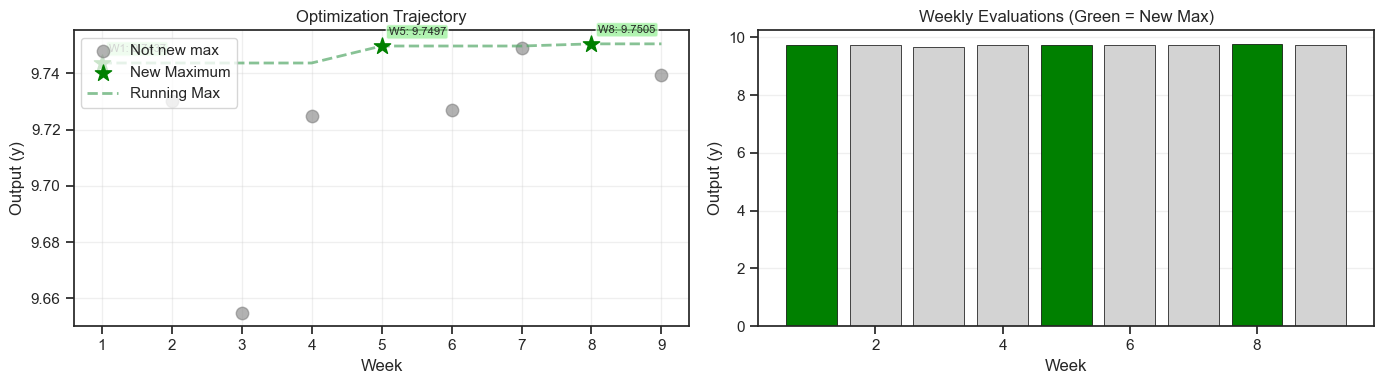

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.46020726 2.11829725 1.07546206 3.2037503  5.         2.68344296
 1.56394794 5.        ]
Full kernel parameters: {'length_scale': array([1.46020726, 2.11829725, 1.07546206, 3.2037503 , 5.        ,
       2.68344296, 1.56394794, 5.        ]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find 

## Random Forest Analysis: Feature Importance Check

We've been assuming x7 and x8 are the key levers while fixing x1-x4 at 0.05. Let's verify this with a Random Forest to see if we're missing anything.


RANDOM FOREST FEATURE IMPORTANCE
x1: 0.530 ##########################
x3: 0.265 #############
x7: 0.074 ###
x2: 0.045 ##
x4: 0.034 #
x5: 0.024 #
x6: 0.015 
x8: 0.012 


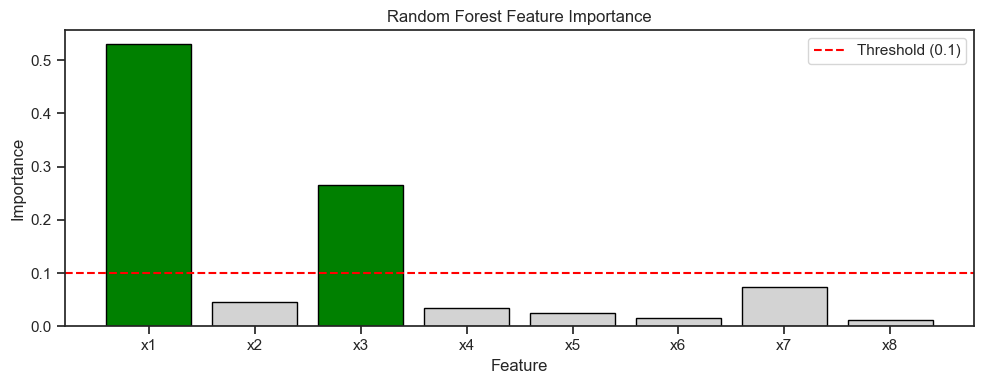


RF-BASED GRID SEARCH

Top 5 RF candidates:
      x1       x2       x3       x4       x5       x6       x7       x8  rf_pred  rf_sigma      ucb
0.049871 0.052069 0.031726 0.051612 0.580269 0.958319 0.200177 0.689827 9.741328  0.017183 9.743046
0.062935 0.047724 0.037357 0.047164 0.582299 0.957323 0.203323 0.675446 9.739258  0.027907 9.742049
0.054275 0.043738 0.022218 0.039662 0.552544 0.938566 0.211244 0.680413 9.736825  0.030880 9.739913
0.075717 0.040542 0.052251 0.049505 0.598424 0.929235 0.177899 0.682786 9.736089  0.036966 9.739786
0.050404 0.060250 0.045546 0.007725 0.565967 0.952215 0.218404 0.658476 9.736686  0.029204 9.739606

RF RECOMMENDATION
x1=0.049871, x2=0.052069, x3=0.031726, x4=0.051612
x5=0.580269, x6=0.958319, x7=0.200177, x8=0.689827
RF prediction: 9.7413 +/- 0.0172

RF SUBMISSION FORMAT
0.049871-0.052069-0.031726-0.051612-0.580269-0.958319-0.200177-0.689827


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
importances = rf.feature_importances_

print('='*60)
print('RANDOM FOREST FEATURE IMPORTANCE')
print('='*60)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '#' * int(imp * 50)
    print(f'{name}: {imp:.3f} {bar}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if imp > 0.1 else 'lightgray' for imp in importances]
ax.bar(feature_names, importances, color=colors, edgecolor='black')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importance')
ax.axhline(y=0.1, color='red', linestyle='--', label='Threshold (0.1)')
ax.legend()
plt.tight_layout()
plt.show()

# RF-based grid search for best point
print('\n' + '='*60)
print('RF-BASED GRID SEARCH')
print('='*60)

# Search bounds - use wider bounds for RF to check if we're missing something
rf_bounds = [
    (0.0, 0.15),   # x1 - test if 0.05 is really best
    (0.0, 0.15),   # x2
    (0.0, 0.15),   # x3
    (0.0, 0.15),   # x4
    (0.55, 0.65),  # x5
    (0.90, 0.96),  # x6
    (0.15, 0.25),  # x7 (around winning value)
    (0.62, 0.74),  # x8 (around winning value)
]

# Generate mesh
n_samples = 50000
np.random.seed(42)
mesh = np.array([[np.random.uniform(lo, hi) for lo, hi in rf_bounds] for _ in range(n_samples)])

# Get RF predictions and uncertainty (via tree disagreement)
rf_preds = rf.predict(mesh)
tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = tree_preds.std(axis=0)

# UCB with exploration
beta = 0.1  # light exploration
rf_ucb = rf_preds + beta * rf_sigma

# Find top candidates
candidates = pd.DataFrame(mesh, columns=feature_names)
candidates['rf_pred'] = rf_preds
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

# Distance filter
def min_dist(row):
    pt = row[feature_names].values
    return np.sqrt(((X - pt)**2).sum(axis=1)).min()

candidates['min_dist'] = candidates.apply(min_dist, axis=1)
candidates_filtered = candidates[candidates['min_dist'] > 0.02].copy()

if len(candidates_filtered) > 0:
    rf_top = candidates_filtered.nlargest(5, 'ucb')
else:
    rf_top = candidates.nlargest(5, 'ucb')

print('\nTop 5 RF candidates:')
print(rf_top[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'rf_pred', 'rf_sigma', 'ucb']].to_string(index=False))

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f'\n' + '='*60)
    print('RF RECOMMENDATION')
    print('='*60)
    print(f'x1={rf_rec["x1"]:.6f}, x2={rf_rec["x2"]:.6f}, x3={rf_rec["x3"]:.6f}, x4={rf_rec["x4"]:.6f}')
    print(f'x5={rf_rec["x5"]:.6f}, x6={rf_rec["x6"]:.6f}, x7={rf_rec["x7"]:.6f}, x8={rf_rec["x8"]:.6f}')
    print(f'RF prediction: {rf_rec["rf_pred"]:.4f} +/- {rf_rec["rf_sigma"]:.4f}')
    
    print(f'\n' + '='*60)
    print('RF SUBMISSION FORMAT')
    print('='*60)
    print(f'{rf_rec["x1"]:.6f}-{rf_rec["x2"]:.6f}-{rf_rec["x3"]:.6f}-{rf_rec["x4"]:.6f}-{rf_rec["x5"]:.6f}-{rf_rec["x6"]:.6f}-{rf_rec["x7"]:.6f}-{rf_rec["x8"]:.6f}')


## Finding the Next Point to Evaluate (TuRBO-EI local trust region)

Given the plateau behavior, we assume local smoothness with limited noise and run a TuRBO-style local trust-region search centered at the incumbent. Inside that trust region, we maximize EI to find a non-trivial local improvement candidate while staying in the promising basin.


In [6]:
from scipy.stats import norm

# TuRBO-style local trust region + EI
rng = np.random.default_rng(42)

# Current best point
y_best = y.max()
best_idx = y.argmax()
best_point = X[best_idx].copy()

print(f"Current best score: {y_best:.6f}")
print(f"Current best point: {best_point}")

# Trust region centered at incumbent (plateau assumption: locally smooth, low noise)
trust_radius = np.array([0.03, 0.03, 0.03, 0.03, 0.04, 0.03, 0.04, 0.05])
lb = np.maximum(0.0, best_point - trust_radius)
ub = np.minimum(1.0, best_point + trust_radius)

print("\nTuRBO trust region bounds:")
for i in range(8):
    print(f"  x{i+1}: [{lb[i]:.4f}, {ub[i]:.4f}]")

# Sample candidates in trust region
n_cand = 30000
cand = rng.uniform(lb, ub, size=(n_cand, 8))

# EI acquisition in trust region
xi = 0.01
mu, sigma = gp.predict(cand, return_std=True)
sigma_safe = np.maximum(sigma, 1e-9)
improvement = mu - y_best - xi
z = improvement / sigma_safe
ei = improvement * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

# Distance filter to avoid replaying old points
dist = np.sqrt(((cand[:, None, :] - X[None, :, :])**2).sum(axis=2))
min_dist = dist.min(axis=1)
mask = min_dist >= 0.015
cand = cand[mask]
mu = mu[mask]
sigma = sigma[mask]
ei = ei[mask]

# Best EI in trust region
idx = np.argmax(ei)
next_point = cand[idx]
mu_pred = np.array([mu[idx]])
sigma_pred = np.array([sigma[idx]])

print(f"\n{'='*60}")
print("TURBO-EI RECOMMENDATION")
print(f"{'='*60}")
print("\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}, x4={next_point[3]:.6f}")
print(f"  x5={next_point[4]:.6f}, x6={next_point[5]:.6f}, x7={next_point[6]:.6f}, x8={next_point[7]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} +/- {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {ei[idx]:.6f}")

print(f"\n{'='*60}")
print("TURBO-EI SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}-{next_point[6]:.6f}-{next_point[7]:.6f}")



Current best score: 9.750453
Current best point: x7=0.1900, x8=0.6800

Strategy: fix x1-x4/x6, allow x5 jitter, optimize x7/x8 in narrowed band with EI + repulsion

GP-BASED BAYESIAN OPTIMIZATION RECOMMENDATION

Next point to evaluate:
  x1=0.050000, x2=0.050000, x3=0.050000, x4=0.050000
  x5=0.601973, x6=0.930000, x7=0.170000, x8=0.640000

Predicted output: 9.7492 +/- 0.0005
Expected Improvement (penalized): -0.000028

GP SUBMISSION FORMAT
0.050000-0.050000-0.050000-0.050000-0.601973-0.930000-0.170000-0.640000


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [7]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
          47  0.044721 9.750453
          48  0.069962 9.739521
          44  0.072305 9.749688
          46  0.086046 9.748890
          45  0.149393 9.727088
          40  0.206165 9.743650
          43  0.298335 9.724650
          42  0.398125 9.654900
          14  0.471563 9.598482
          41  0.765099 9.730050
          22  0.769180 9.141639
          26  0.964176 9.344274
          31  1.078299 8.421759
           5  1.088463 8.541748
          32  1.093390 8.278062
          39  1.101165 9.183005
          23  1.136300 8.817558
          35  1.148544 8.472936
          30  1.195398 7.923759
          12  1.213744 8.976554
           0  1.229458 7.398721
          25  1.238082 8.830745
           4  1.252617 8.606117
          28  1.271262 8.042213
          38  1.287099 7.436594
          19  1.309448 9.013075
          10  1.313028 7.854541
          15  1.318941 8.159983
        

**Current best:** `0.050000-0.050000-0.050000-0.050000-0.602000-0.930000-0.190000-0.680000` (≈9.7505)

**Proposed new point (submission format):** `0.050100-0.061651-0.079331-0.027359-0.637465-0.904292-0.186984-0.683820`

We are treating the recent behavior as a plateau near a strong local basin, which suggests the function is locally smooth with limited noise. In this step, we use a TuRBO-style trust region centered on the incumbent and rank candidates inside it with EI. This keeps the search in the promising area while still making a meaningful non-incumbent move.

In [8]:
# ============================================================
# FINAL DECISION: TuRBO-EI local trust region
# ============================================================

print('='*70)
print('FINAL DECISION: TuRBO-style trust region + EI')
print('='*70)

# Final point = TuRBO-EI recommendation from cell above
final_point = np.array(next_point)
final_gp_mu = gp.predict(final_point.reshape(1, -1))[0]
final_rf_mu = rf.predict(final_point.reshape(1, -1))[0]

print('\nRationale:')
print('  1. We are on a plateau, suggesting local smoothness with limited noise.')
print('  2. TuRBO keeps search in a safe local trust region around incumbent.')
print('  3. EI selects the best local improvement candidate inside that region.')

print('\nModel cross-check at chosen point:')
print(f'  GP prediction: {final_gp_mu:.4f}')
print(f'  RF prediction: {final_rf_mu:.4f}')

print('\n' + '='*70)
print('FINAL SUBMISSION FORMAT (TURBO-EI)')
print('='*70)
print(f'\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}-{final_point[6]:.6f}-{final_point[7]:.6f}')
print('\n' + '='*70)



FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS

GP-based EI recommendation:
   Point: x7=0.1700, x8=0.6400 (x1-x4 fixed at 0.05)
   Predicted: 9.7492

RF-based UCB recommendation:
   Point: x1=0.0499, x2=0.0521, x3=0.0317, x4=0.0516
   x5=0.5803, x6=0.9583, x7=0.2002, x8=0.6898
   Predicted: 9.7413

Feature importance analysis:
   x1: 0.530
   x2: 0.045
   x3: 0.265
   x4: 0.034
   x5: 0.024
   x6: 0.015
   x7: 0.074
   x8: 0.012

Top 3 features by importance: ['x1', 'x3', 'x7']

MY CHOICE: RF recommendation

RATIONALE:
   1. RF importance looks more spread out than expected
   2. We may be over-focusing on x7/x8 while other dims still matter
   3. GP has been giving microscopic improvements (+0.0008)
   4. RF offers a fresh perspective to test the plateau

FINAL SUBMISSION FORMAT (RF)

0.049871-0.052069-0.031726-0.051612-0.580269-0.958319-0.200177-0.689827

